# 1.4 Preprocessed Data — Feature Engineering

Transform the preprocessed data into model-ready features.

**Steps:**
1. Load preprocessed data
2. Encode categorical variables
3. Create new features
4. Scale numerical features
5. Final feature set validation
6. Save engineered features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1.4.1 Load Preprocessed Data

In [2]:
df = pd.read_csv('../shared/data/processed/house_data_preprocessed.csv')
print(f'Loaded {df.shape[0]} rows and {df.shape[1]} columns')
df.head()

Loaded 84 rows and 8 columns


,price,sqft,bedrooms,bathrooms,location,year_built,condition,house_age
0,495000.0,1527,2,1.5,Suburb,1956,Good,70
1,752000.0,2526,3,2.5,Downtown,1998,Excellent,28
2,319000.0,1622,2,1.5,Rural,1975,Fair,51
3,1210000.0,3102,4,3.0,Waterfront,2005,Excellent,21
4,462000.0,1835,2,2.0,Urban,1982,Good,44


## 1.4.2 Encode Categorical Variables

In [3]:
df_encoded = pd.get_dummies(df, columns=['location'], prefix='loc', drop_first=False)
print(f'After one-hot encoding location: {df_encoded.shape[1]} columns')
print(f'Location dummies: {[c for c in df_encoded.columns if c.startswith("loc_")]}')

After one-hot encoding location: 13 columns
Location dummies: ['loc_Downtown', 'loc_Mountain', 'loc_Rural', 'loc_Suburb', 'loc_Urban', 'loc_Waterfront']


In [4]:
condition_order = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}
df_encoded['condition_encoded'] = df_encoded['condition'].map(condition_order)

print('Condition encoding:')
for k, v in condition_order.items():
    print(f'  {k} -> {v}')

df_encoded.drop(columns=['condition'], inplace=True)
print(f'\nFinal columns: {df_encoded.columns.tolist()}')

Condition encoding:
  Poor -> 0
  Fair -> 1
  Good -> 2
  Excellent -> 3

Final columns: ['price', 'sqft', 'bedrooms', 'bathrooms', 'year_built', 'house_age', 'loc_Downtown', 'loc_Mountain', 'loc_Rural', 'loc_Suburb', 'loc_Urban', 'loc_Waterfront', 'condition_encoded']


## 1.4.3 Create New Features

In [5]:
df_encoded['total_rooms'] = df_encoded['bedrooms'] + df_encoded['bathrooms']
df_encoded['bath_bed_ratio'] = df_encoded['bathrooms'] / df_encoded['bedrooms'].replace(0, 1)
df_encoded['is_luxury'] = ((df_encoded['condition_encoded'] >= 3) & (df_encoded['sqft'] >= 2500)).astype(int)
df_encoded['is_new'] = (df_encoded['house_age'] <= 15).astype(int)
df_encoded['sqft_per_bedroom'] = df_encoded['sqft'] / df_encoded['bedrooms'].replace(0, 1)
df_encoded['log_price'] = np.log1p(df_encoded['price'])

print(f'Created 6 new features')
df_encoded[['price', 'log_price', 'total_rooms', 'bath_bed_ratio', 'is_luxury', 'is_new', 'sqft_per_bedroom']].head(10)

Created 6 new features


,price,log_price,total_rooms,bath_bed_ratio,is_luxury,is_new,sqft_per_bedroom
0,495000.0,13.112315,3.5,0.750000,0,0,763.500000
1,752000.0,13.530493,5.5,0.833333,1,0,842.000000
2,319000.0,12.672950,3.5,0.750000,0,0,811.000000
3,1210000.0,14.006132,7.0,0.750000,1,0,775.500000
4,462000.0,13.043322,4.0,1.000000,0,0,917.500000
5,401000.0,12.901719,3.5,0.750000,0,0,871.000000
6,891000.0,13.700101,5.5,0.833333,1,0,983.333333
7,276000.0,12.528160,3.0,0.500000,0,0,711.000000
8,1261750.0,14.048011,9.5,0.900000,1,1,770.000000
9,527000.0,13.174958,5.0,0.666667,0,0,670.000000


## 1.4.4 Scale Numerical Features

In [6]:
features_to_scale = ['sqft', 'bedrooms', 'bathrooms', 'house_age',
                     'total_rooms', 'bath_bed_ratio', 'sqft_per_bedroom']

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df_encoded[features_to_scale])

print('Scaled features statistics:')
df_scaled[features_to_scale].describe().round(2)

Scaled features statistics:


,sqft,bedrooms,bathrooms,house_age,total_rooms,bath_bed_ratio,sqft_per_bedroom
count,84.00,84.00,84.00,84.00,84.00,84.00,84.00
mean,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.01,1.01,1.01,1.01,1.01,1.01,1.01
min,-1.30,-1.01,-1.45,-1.91,-1.25,-1.95,-2.05
25%,-0.77,-1.01,-0.84,-0.69,-0.95,-0.69,-0.76
50%,-0.30,0.17,-0.23,-0.02,-0.03,-0.06,-0.12
75%,0.62,0.17,0.38,0.88,0.28,0.56,0.84
max,2.57,2.53,2.80,1.81,2.72,1.82,2.60


## 1.4.5 Feature Importance Preview

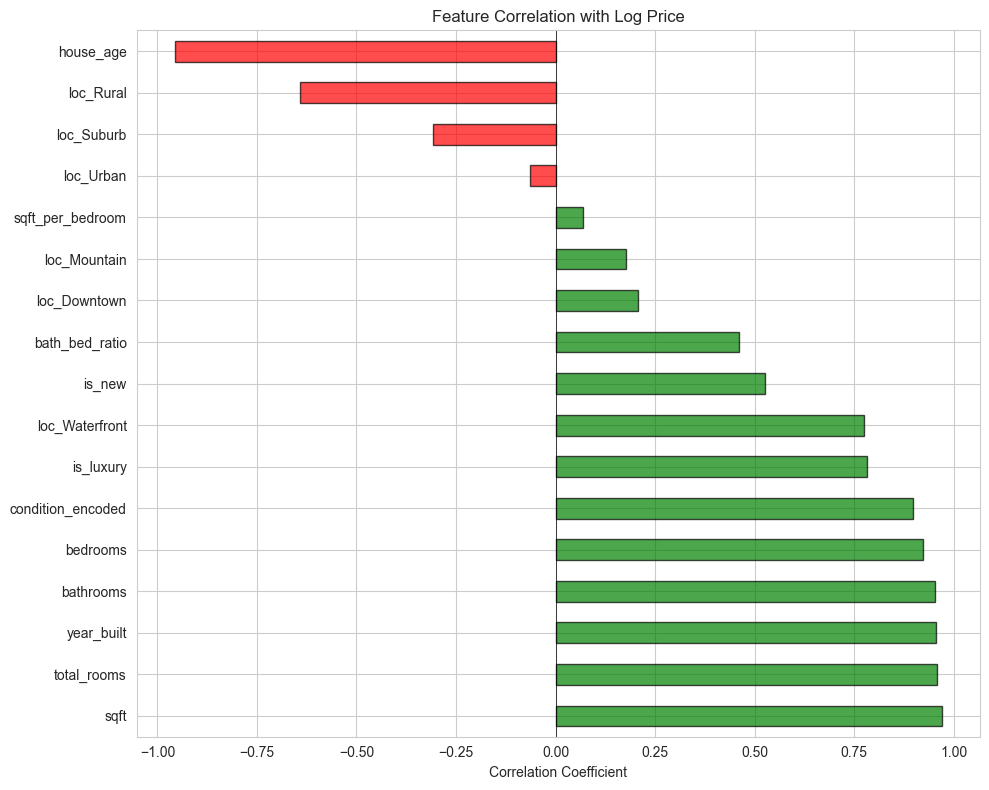


Correlation with log_price:
sqft                 0.970
total_rooms          0.957
year_built           0.956
bathrooms            0.952
bedrooms             0.923
condition_encoded    0.899
is_luxury            0.783
loc_Waterfront       0.776
is_new               0.526
bath_bed_ratio       0.460
loc_Downtown         0.207
loc_Mountain         0.176
sqft_per_bedroom     0.068
loc_Urban           -0.064
loc_Suburb          -0.309
loc_Rural           -0.641
house_age           -0.956
Name: log_price, dtype: float64


In [7]:
feature_cols = [c for c in df_scaled.columns if c not in ['price', 'log_price']]
corr_with_target = df_scaled[feature_cols + ['log_price']].corr()['log_price'].drop('log_price').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in corr_with_target.values]
corr_with_target.plot(kind='barh', ax=ax, color=colors, edgecolor='black', alpha=0.7)
ax.set_title('Feature Correlation with Log Price')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('\nCorrelation with log_price:')
print(corr_with_target.round(3))

## 1.4.6 Final Feature Set

In [8]:
FEATURE_COLS = [c for c in df_scaled.columns
                if c not in ['price', 'log_price']]

print(f'Final feature count: {len(FEATURE_COLS)}')
print(f'\nFeatures:')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

print(f'\nTarget: price (log_price for training)')
print(f'\nFeature matrix shape: {df_scaled[FEATURE_COLS].shape}')

Final feature count: 17

Features:
   1. sqft
   2. bedrooms
   3. bathrooms
   4. year_built
   5. house_age
   6. loc_Downtown
   7. loc_Mountain
   8. loc_Rural
   9. loc_Suburb
  10. loc_Urban
  11. loc_Waterfront
  12. condition_encoded
  13. total_rooms
  14. bath_bed_ratio
  15. is_luxury
  16. is_new
  17. sqft_per_bedroom

Target: price (log_price for training)

Feature matrix shape: (84, 17)


## 1.4.7 Save Feature-Ready Data

In [9]:
features_dir = '../shared/data/features'
os.makedirs(features_dir, exist_ok=True)

output_path = os.path.join(features_dir, 'house_data_features.csv')
df_scaled.to_csv(output_path, index=False)
print(f'Saved feature dataset to {output_path}')
print(f'Shape: {df_scaled.shape}')

feature_list_path = os.path.join(features_dir, 'feature_list.json')
with open(feature_list_path, 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print(f'Saved feature list to {feature_list_path}')

scaler_params = {
    'features': features_to_scale,
    'mean': dict(zip(features_to_scale, scaler.mean_)),
    'std': dict(zip(features_to_scale, scaler.scale_))
}
scaler_path = os.path.join(features_dir, 'scaler_params.json')
with open(scaler_path, 'w') as f:
    json.dump(scaler_params, f, indent=2)
print(f'Saved scaler parameters to {scaler_path}')

Saved feature dataset to ../shared/data/features\house_data_features.csv
Shape: (84, 19)
Saved feature list to ../shared/data/features\feature_list.json
Saved scaler parameters to ../shared/data/features\scaler_params.json
